In [15]:
import numpy as np
import matplotlib.pyplot as plt

def check_dataset(id_to_check=29, file_path="training_data_lv_aorta.npz", ):
    # 1. Adatok betöltése
    try:
        data = np.load(file_path)
    except FileNotFoundError:
        print(f"Hiba: Nem találom a {file_path} fájlt!")
        return

    X = data['X']
    y = data['y']
    ids = data['ids']

    # 2. Alapvető információk kiírása
    print("--- ADATHALMAZ STATISZTIKA ---")
    print(f"Kulcsok a fájlban: {list(data.keys())}")
    print(f"X (Jellemzők) alakja: {X.shape}")
    print(f"y (Célváltozó) alakja: {y.shape}")
    print(f"Mentett ID-k száma: {len(ids)}")
    print(f"Első 3 ID: {ids[:3]}\n")

    # NaN vagy végtelen értékek ellenőrzése
    if np.isnan(X).any() or np.isinf(X).any():
        print("FIGYELEM: NaN vagy végtelen (Inf) értékek vannak az X tenzorban!")
    else:
        print("X tenzor tiszta (nincs NaN/Inf).")

    # 3. Vizuális ellenőrzés (Nézzük meg az első mintát)
    sample_idx = id_to_check  # Ezt átírhatod, hogy más CT-ket is megnézz (0-29 között)
    current_id = ids[sample_idx]

    # A feature_cols sorrendje alapján: 
    # ['Tubeness', 'Radius', 'L1', 'L2', 'L3', 'Norm_Z', 'Norm_Y', 'Norm_X']
    tubeness = X[sample_idx, :, 3]  # 3. oszlop = Tubeness
    radius   = X[sample_idx, :, 4]  # 4. oszlop = Radius
    target_curve = y[sample_idx, :]

    # Plotolás
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.set_title(f"Adat ellenőrzése - ID: {current_id}")
    ax1.set_xlabel("Index az út mentén (0-99)")
    
    # Tubeness rajzolása az első Y tengelyre
    color1 = 'tab:blue'
    ax1.set_ylabel('Tubeness', color=color1)
    ax1.plot(tubeness, label='Tubeness (Jellemző)', color=color1, linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    ax2 = ax1.twinx()  
    color2 = 'tab:green'
    ax2.set_ylabel('Radius', color=color2)
    ax2.plot(radius, label='Radius (Jellemző)', color=color2, linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color2)

    # Célváltozó (Gauss) rajzolása egy második Y tengelyre
    ax3 = ax1.twinx()  
    color3 = 'tab:red'
    ax3.set_ylabel('Célváltozó (Gauss)', color=color3)
    ax3.plot(target_curve, label='Célváltozó (y)', color=color3, linestyle='--', linewidth=2)
    ax3.tick_params(axis='y', labelcolor=color3)

    fig.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

Adathalmaz ellenőrzése...
--- ADATHALMAZ STATISZTIKA ---
Kulcsok a fájlban: ['X', 'y', 'ids']
X (Jellemzők) alakja: (30, 100, 11)
y (Célváltozó) alakja: (30, 100)
Mentett ID-k száma: 30
Első 3 ID: ['LIDC-IDRI-0004_aorta' 'LIDC-IDRI-0010_aorta' 'LIDC-IDRI-0012_aorta']

X tenzor tiszta (nincs NaN/Inf).


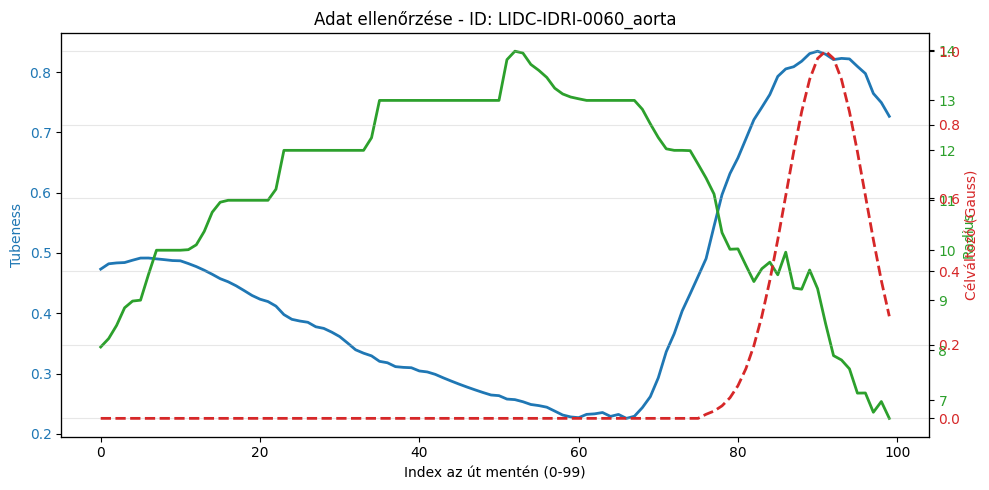

In [16]:
print("Adathalmaz ellenőrzése...")
check_dataset(id_to_check=10)

In [1]:
import argparse
import os
import numpy as np
import SimpleITK as sitk

from soveny import tube_BB
from soveny import config
from soveny import input
from soveny import label
from soveny import ventircles_BB
from soveny import visualization
from soveny import septum_BB
from soveny import filter
from soveny import output
from soveny import resample

In [1]:
import shutil
from pathlib import Path

# --- Beállítások ---
# Az LIDC mappák gyökérkönyvtára
input_dir = Path(r"C:\Users\somas\Desktop\25262\Onlab\project_soveny\output\lidc")

# A célmappa, ahova a kigyűjtött képek kerülnek
output_dir = Path(r"C:\Users\somas\Desktop\25262\Onlab\project_soveny\collected_tubeness_images")

# --- Futtatás ---
def collect_tubeness_images():
    # Ha a célmappa nem létezik, létrehozza
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Megkeressük az összes tubeness_along_skeleton.png fájlt rekurzívan
    image_paths = list(input_dir.rglob("tubeness_along_skeleton.png"))
    
    if not image_paths:
        print("Nem található megfelelő kép a megadott mappában.")
        return

    for img_path in image_paths:
        # 1. A vágási sík mappájának neve (pl. "aorta_cutting_plane" vagy "artery_cutting_plane")
        plane_folder_name = img_path.parent.name
        # Kinyerjük a struktúra nevét a mappából ("aorta" vagy "artery")
        structure_name = plane_folder_name.split('_')[0] 
        
        # 2. A beteg mappájának neve (pl. "LIDC-IDRI-0004")
        lidc_folder_name = img_path.parent.parent.name
        # Kinyerjük a 4 jegyű azonosítót a kötőjelek mentén darabolva
        patient_id = lidc_folder_name.split('-')[-1]
        
        # 3. Új fájlnév összeállítása (pl. "0004_aorta.png")
        new_filename = f"{patient_id}_{structure_name}.png"
        new_filepath = output_dir / new_filename
        
        # 4. Fájl másolása (a copy2 megtartja a metaadatokat is)
        shutil.copy2(img_path, new_filepath)
        
        print(f"Sikeres másolás: {lidc_folder_name}/{plane_folder_name}/... -> {new_filename}")

    print(f"\nKész! Összesen {len(image_paths)} kép lett kimentve ide: {output_dir}")

if __name__ == "__main__":
    collect_tubeness_images()

Sikeres másolás: LIDC-IDRI-0164/aorta_cutting_plane/... -> 0164_aorta.png
Sikeres másolás: LIDC-IDRI-0164/artery_cutting_plane/... -> 0164_artery.png
Sikeres másolás: LIDC-IDRI-0161/aorta_cutting_plane/... -> 0161_aorta.png
Sikeres másolás: LIDC-IDRI-0161/artery_cutting_plane/... -> 0161_artery.png
Sikeres másolás: LIDC-IDRI-0137/aorta_cutting_plane/... -> 0137_aorta.png
Sikeres másolás: LIDC-IDRI-0137/artery_cutting_plane/... -> 0137_artery.png
Sikeres másolás: LIDC-IDRI-0133/aorta_cutting_plane/... -> 0133_aorta.png
Sikeres másolás: LIDC-IDRI-0133/artery_cutting_plane/... -> 0133_artery.png
Sikeres másolás: LIDC-IDRI-0129/aorta_cutting_plane/... -> 0129_aorta.png
Sikeres másolás: LIDC-IDRI-0129/artery_cutting_plane/... -> 0129_artery.png
Sikeres másolás: LIDC-IDRI-0128/aorta_cutting_plane/... -> 0128_aorta.png
Sikeres másolás: LIDC-IDRI-0128/artery_cutting_plane/... -> 0128_artery.png
Sikeres másolás: LIDC-IDRI-0124/aorta_cutting_plane/... -> 0124_aorta.png
Sikeres másolás: LIDC-IDRI


--- Feldolgozás alatt: LIDC-IDRI-0031.nii.gz ---
Output directory: output\lidc\LIDC-IDRI-0031


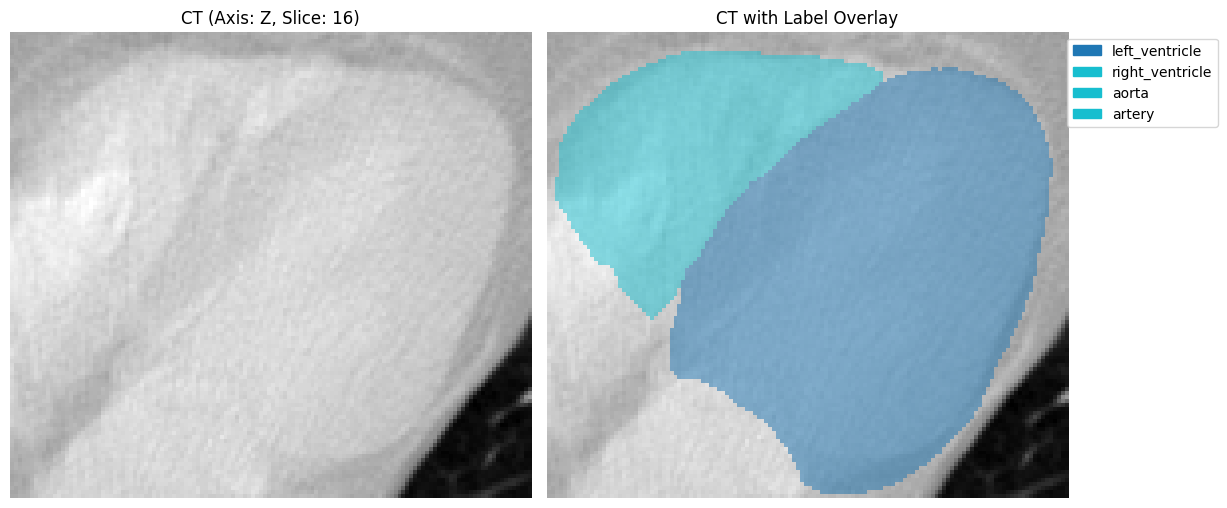

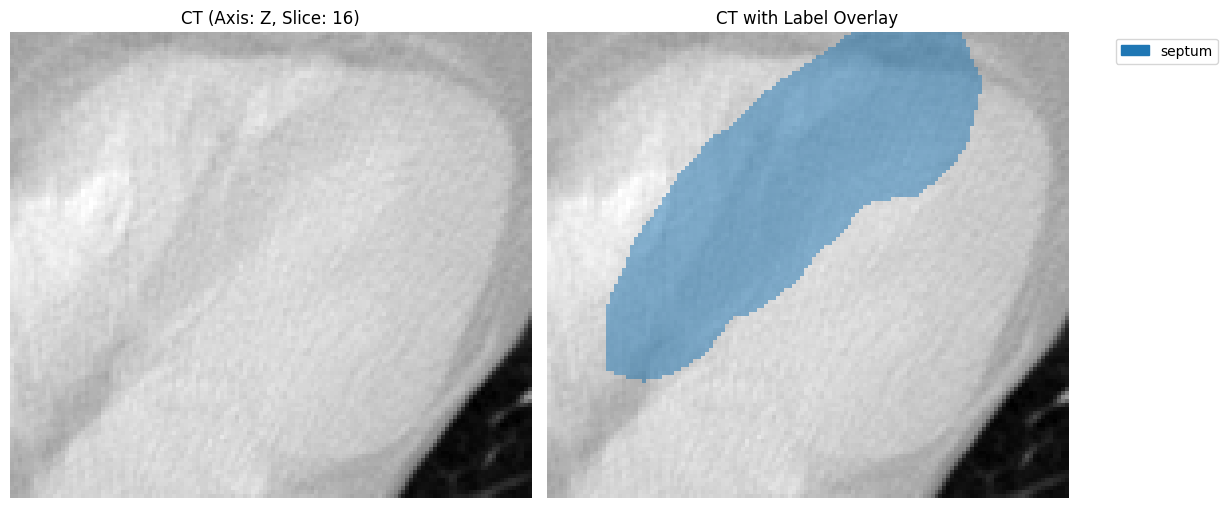

In [2]:
from pathlib import Path

dataset_dir, cfg = config.load_config("lidc")
image_path, label_path = input.get_input_paths(dataset_dir)
print(f"\n--- Feldolgozás alatt: {os.path.basename(image_path)} ---")
ct_image, ct_array, _, label_array = input.load_ct_and_label(image_path, label_path)

output.set_reference(ct_image)

output_dir = output.derive_output_dir(image_path, "lidc")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

relevant_labels_dic = label.extract_labels(label_array, cfg)

roi_mask = relevant_labels_dic['left_ventricle'] | relevant_labels_dic['right_ventricle']

cropped_ct_array, cropped_relevant_labels_dic = ventircles_BB.crop_to_roi(
    ct_array, 
    relevant_labels_dic, 
    roi_mask
)

visualization.plot_slice_with_labels(cropped_ct_array, cropped_relevant_labels_dic, axis='z', save_path=os.path.join(output_dir, 'ventricles_overlay.png'))

septum_mask = septum_BB.get_septum_by_distance(
    cropped_relevant_labels_dic['left_ventricle'],
    cropped_relevant_labels_dic['right_ventricle'],
    max_distance_mm=15
)

visualization.plot_slice_with_labels(cropped_ct_array, {'septum': septum_mask,}, axis='z', save_path=os.path.join(output_dir, 'septum_overlay.png'))


In [3]:
import os
from networkx import radius
import numpy as np
import pandas as pd
import scipy.ndimage as ndimage
from skimage.draw import line_nd
from skimage.morphology import skeletonize
from scipy.ndimage import binary_dilation, distance_transform_edt
import SimpleITK as sitk
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt


In [44]:
"""
Keres egy vágósíkot a kamra és a cső (pl. aorta) között, amely elválasztja a kettőt.

Args:
    ventricle_label: a kamra maszkja (pl. bal kamra)
    tube_label: a cső maszkja (pl. aorta)
    ct_array: A CT kép a vizualizációhoz (opcionális)
    ct_image: A CT kép a vizualizációhoz (opcionális)
    out_dir: A kimeneti könyvtár elérési útvonala (opcionális)
    ventricle_type: A kamra típusa (pl. bal kamra)
    tube_type: A cső típusa (pl. aorta)
Returns:
    df.DataFrame: A vágási jellemzőket tartalmazó DataFrame.
"""

ventricle_label = relevant_labels_dic['right_ventricle']
tube_label = relevant_labels_dic['artery']
ct_array = ct_array
ct_image = ct_image
out_dir = os.path.join(output_dir, "artery_cutting_plane")
tube_type = 'artery'
ventricle_type = 'right_ventricle'

scale = 30.0

smoothed_ventricle = tube_BB.get_smoothed_ventricle(ventricle_label, output_dir=out_dir)
dist_to_ventricle = distance_transform_edt(~smoothed_ventricle)

smoothed_tube = tube_BB.get_smoothed_tube(tube_label, output_dir=out_dir)
while True:

    smoothed = tube_BB.get_smoothed_unio(scale=scale, smoothed_ventricle=smoothed_ventricle, dist_to_ventricle=dist_to_ventricle, extended_tube=smoothed_tube)
    skeleton = skeletonize(smoothed)
    
    # Szigetek keresése 26-os szomszédsággal
    struct_26 = ndimage.generate_binary_structure(3, 3)
    labeled_skeleton, num_features = ndimage.label(skeleton, structure=struct_26)
    
    if num_features > 0:
        # Legnagyobb sziget megkeresése (a bincount 0. eleme a háttér, azt kihagyjuk)
        sizes = np.bincount(labeled_skeleton.flat)[1:]
        largest_label = np.argmax(sizes) + 1
        main_skeleton = (labeled_skeleton == largest_label)
        
        main_path = tube_BB.get_shortest_path_between_farest_points(main_skeleton, smooth_factor=100.0)
        
        main_path_mask = np.zeros_like(main_skeleton, dtype=np.uint8)
        if len(main_path) > 0:
            main_path_mask[tuple(main_path.T)] = 1            
        # a main path nem csak a kamrában, de a csőben is megy, akkor az jó
        if tube_label[main_path_mask.astype(bool)].sum() > 3:
            dilated_skeleton = ndimage.binary_dilation(main_skeleton, iterations=1)
            output.save_image(dilated_skeleton.astype(np.uint8), os.path.join(out_dir, "dilated_main_skeleton.nii.gz"))
            output.save_image(smoothed.astype(np.uint8), os.path.join(out_dir, "smoothed.nii.gz"))
            dilated_main_path = ndimage.binary_dilation(main_path_mask, iterations=1)
            output.save_image(dilated_main_path.astype(np.uint8), os.path.join(out_dir, "dilated_main_path.nii.gz"))
            break
        else:
            scale += 7.0
    else:
        scale += 9.0
        
# Region of Interest meghatározása az átmenet kereséséhez, a fő vonal felső 10%-a
cut_len = int(len(main_path) * 0.9) 
bottleneck_path = main_path[cut_len:]

# ellenörzésképpen mentjük a fő vonalat és a bottleneck régiót is
bottleneck_mask = np.zeros_like(main_path_mask, dtype=np.uint8)
if len(bottleneck_path) > 0:
    bottleneck_mask[tuple(bottleneck_path.T)] = 1
# dilatáljuk egy kicsit, hogy jobban látszódjon a vizualizációkon
bottleneck_mask = ndimage.binary_dilation(bottleneck_mask, iterations=1)
output.save_image(bottleneck_mask.astype(np.uint8), os.path.join(out_dir, "bottleneck_mask.nii.gz"))

distance_map = distance_transform_edt(smoothed.astype(bool))
if len(bottleneck_path) > 0:
    radii_in_voxels = distance_map[tuple(bottleneck_path.T)] # át kell alakítani koordinátákká
else:
    radii_in_voxels = []

if len(radii_in_voxels) > 0:
    min_r = np.min(radii_in_voxels)
    max_r = np.max(radii_in_voxels)
    mean_r = np.mean(radii_in_voxels)
    median_r = np.median(radii_in_voxels)
    # Dinamikus sigmák
    dynamic_sigmas = np.linspace(max(min_r, 2.0), max(max_r, 7.0), num=5).tolist()
    #dynamic_sigmas = [1.0, 2.0,  3.0,  4.0, 5.0]
    print(f"Dinamikus sigmák: {dynamic_sigmas}")
else:
    # Ha egyáltalán nincs érték, adjunk egy biztonságos fallback listát!
    dynamic_sigmas = [2.0, 3.0,  4.0, 5.0, 6.0, 7.0]

z_idx, y_idx, x_idx = np.nonzero(smoothed)

z_min: int = max(0, z_idx.min())
z_max: int = min(smoothed.shape[0], z_idx.max() + 1)
    
y_min: int = max(0, y_idx.min())
y_max: int = min(smoothed.shape[1], y_idx.max() + 1)
    
x_min: int = max(0, x_idx.min())
x_max: int = min(smoothed.shape[2], x_idx.max() + 1)

# A szűréshez minimalizáljuk a feldolgozandó területet egy bounding box-szal

# CT kivágása
smoothed_cropped = smoothed[z_min:z_max, y_min:y_max, x_min:x_max]

# A fő vonal alsó 20%-át levágjuk, hogy ez ne zavarjon
#cut_len = int(len(main_path) * 0.2) 
interesting_path = main_path # proba

# EREDETI MÉRETŰ maszkot készítünk, beleírjuk az 1-eseket
interesting_mask_full = np.zeros_like(main_path_mask, dtype=np.uint8)
if len(interesting_path) > 0:
    interesting_mask_full[tuple(interesting_path.T)] = 1
    
# Majd ezt VÁGJUK KI a kisebb bounding boxra
interesting_mask_cropped = interesting_mask_full[z_min:z_max, y_min:y_max, x_min:x_max]
        


Skála: 30.0, Távolság a kamrához és csőhöz: 30.0
Dinamikus sigmák: [6.164414002968976, 6.391077455193101, 6.617740907417225, 6.84440435964135, 7.0710678118654755]


    Z_index  Y_index  X_index  Tubeness    Radius        L1        L2  \
0        56      336      322  0.480680  2.449490  0.050875 -0.115008   
1        56      335      321  0.548373  2.840559  0.035573 -0.129678   
2        56      335      319  0.628013  3.000000  0.004752 -0.141745   
3        56      335      318  0.645965  3.000000 -0.010937 -0.144513   
4        56      335      316  0.653526  3.089550 -0.026238 -0.146727   
..      ...      ...      ...       ...       ...       ...       ...   
95       91      281      268  0.702566  7.000000  0.015672 -0.135938   
96       91      280      268  0.715071  7.055993  0.005923 -0.139757   
97       91      279      268  0.720337  7.010050 -0.005236 -0.143384   
98       92      278      268  0.702761  6.728836 -0.022215 -0.151228   
99       92      277      268  0.684412  7.000000 -0.037666 -0.154818   

          L3    Norm_Z    Norm_Y    Norm_X  
0  -0.217824  0.049357 -0.089202  0.994790  
1  -0.220892  0.046126 -0.128708 

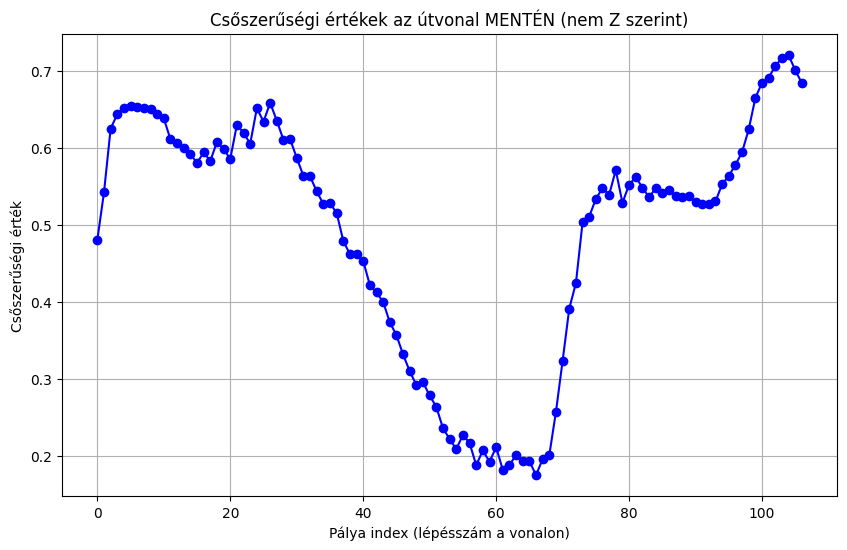

In [53]:
tubeness_result = filter.multiscale_tubeness_3d(
        image=smoothed_cropped.astype(np.float32), 
        sigmas=dynamic_sigmas,
        skeleton=interesting_mask_cropped, 
        alpha=0.2, # annyira nem fontos, hogy a cső két kersztmetszete hasonló legyen 
        beta=0.6,        
    )



# interesting_path még az eredeti térben
path_z_cropped = interesting_path[:, 0] - z_min
path_y_cropped = interesting_path[:, 1] - y_min
path_x_cropped = interesting_path[:, 2] - x_min

# 2. Értékek "kimetszése" a 3D térből PONTOSAN AZ ÚTVONAL SORRENDJÉBEN
scores_on_path = tubeness_result['scores'][path_z_cropped, path_y_cropped, path_x_cropped]
eigenvalues_on_path = tubeness_result['eigenvalues'][path_z_cropped, path_y_cropped, path_x_cropped, :]
eigenvectors_on_path = tubeness_result['eigenvectors'][path_z_cropped, path_y_cropped, path_x_cropped, :]

distance_map_cropped = distance_map[z_min:z_max, y_min:y_max, x_min:x_max]
radii_on_path = distance_map_cropped[path_z_cropped, path_y_cropped, path_x_cropped]

if out_dir:
    plt.figure(figsize=(10, 6))
    # A X tengely mostantól egyszerűen a pontok sorrendje (0, 1, 2, ... N) lesz
    plt.plot(range(len(scores_on_path)), scores_on_path, marker='o', color='blue')
    
    plt.title('Csőszerűségi értékek az útvonal MENTÉN (nem Z szerint)')
    plt.xlabel('Pálya index (lépésszám a vonalon)')
    plt.ylabel('Csőszerűségi érték')
    plt.grid()
    plt.savefig(os.path.join(out_dir, "tubeness_along_skeleton.png"))

# Előjel-ugrások (Hessian-átok) javítása a normálvektorok térbeli folytonosságához
# Mivel a sajátvektor-felbontásnál v és -v is érvényes, szomszédos pontoknál előfordulhat 180 fokos ugrás
for i in range(1, len(eigenvectors_on_path)):
    if np.dot(eigenvectors_on_path[i], eigenvectors_on_path[i-1]) < 0:
        eigenvectors_on_path[i] *= -1
        
# 3. DataFrame összeállítása
import pandas as pd

l1_vec_z = eigenvectors_on_path[:, 0] # Z komponens
l1_vec_y = eigenvectors_on_path[:, 1] # Y komponens
l1_vec_x = eigenvectors_on_path[:, 2] # X komponens

df_features = pd.DataFrame({
    'Z_index': interesting_path[:, 0], # Eredeti Z
    'Y_index': interesting_path[:, 1], # Eredeti Y
    'X_index': interesting_path[:, 2], # Eredeti X
    'Tubeness': scores_on_path,
    'Radius': radii_on_path,
    'L1': eigenvalues_on_path[:, 0],
    'L2': eigenvalues_on_path[:, 1],
    'L3': eigenvalues_on_path[:, 2],
    'Norm_Z': l1_vec_z, # A vágósík normálvektorának Z komponense
    'Norm_Y': l1_vec_y, # A vágósík normálvektorának Y komponense
    'Norm_X': l1_vec_x  # A vágósík normálvektorának X komponense
})

df_resampled = tube_BB.resample_dataframe(df_features)

csv_path = os.path.join(out_dir, "skeleton_features_resampled.csv")
df_resampled.to_csv(csv_path, index=False)

print(df_resampled)




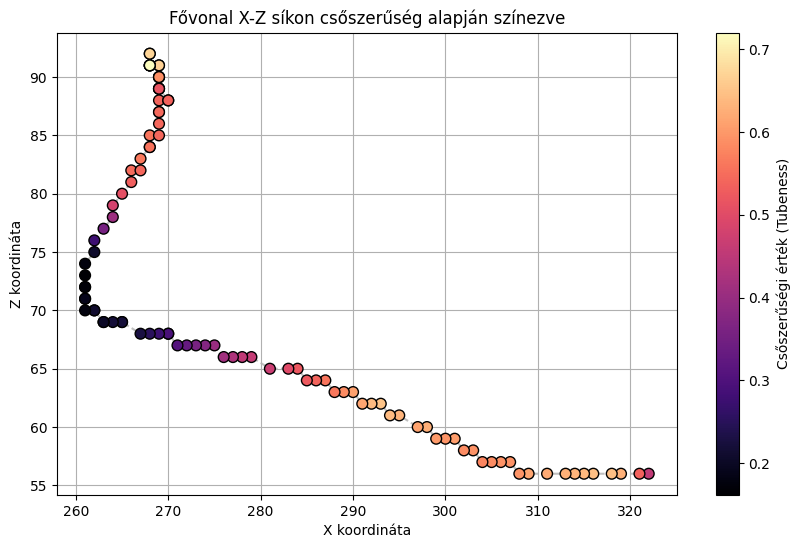

In [50]:
 #--- Új Plot: y tengelyen a Z koordináták, x tengelyen az Y koordináták ---
plt.figure(figsize=(10, 6))

# Adatok kinyerése (itt a resampled DataFrame-t használjuk, hogy egyezzen a kimenettel)
x_coords = df_resampled['X_index']
z_coords = df_resampled['Z_index']
tubeness_scores = df_resampled['Tubeness']

# Vonal kirajzolása halványan a pontok mögé, hogy látszódjon a pálya folytonossága
plt.plot(x_coords, z_coords, color='gray', linestyle='--', alpha=0.5, zorder=1)

# Scatter plot a heatmap szerű megjelenítéshez
# A cmap='magma' vagy 'turbo' nagyon jól mutat orvosi képek analízisénél
scatter = plt.scatter(x_coords, z_coords, c=tubeness_scores, cmap='magma', 
                    s=60, edgecolor='black', zorder=2)

# Színmagyarázat (colorbar) hozzáadása
cbar = plt.colorbar(scatter)
cbar.set_label('Csőszerűségi érték (Tubeness)')

plt.title('Fővonal X-Z síkon csőszerűség alapján színezve')
plt.xlabel('X koordináta')
plt.ylabel('Z koordináta')
plt.grid(True)

plt.show()

# Új fájlnév, hogy ne írja felül az előzőt
plt.savefig(os.path.join(out_dir, "tubeness_xz_heatmap.png"))
plt.close() # Memóriaszivárgás elkerülése miatt érdemes lezárni a plotot

In [7]:
pip install numpy scipy networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Jelenlegi Y metszetindex: 330


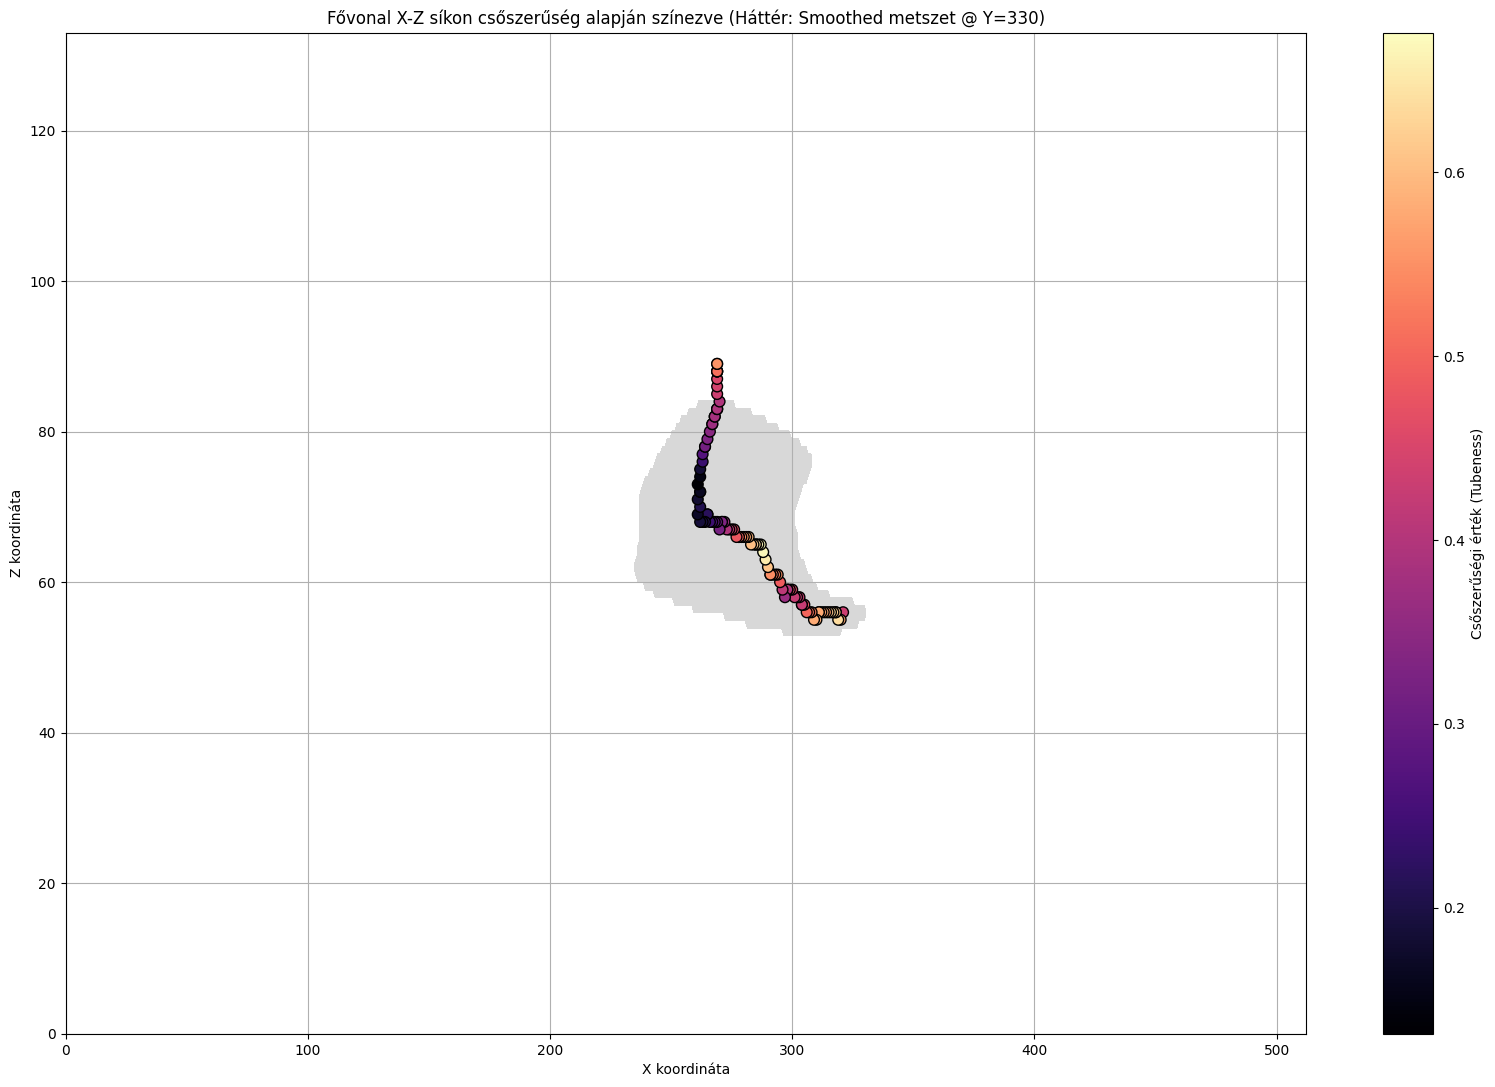

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Feltételezések az integrációhoz ---
# assume df_resampled exists from previous turns
# assume smoothed exists from previous turns as (Z, Y, X) numpy array

#--- Új Plot: y tengelyen a Z koordináták, x tengelyen az Y koordináták ---
plt.figure(figsize=(20, 13)) # Növeljük a méretet a jobb láthatóságért

# Adatok kinyerése
x_coords = df_resampled['X_index']
z_coords = df_resampled['Z_index']
tubeness_scores = df_resampled['Tubeness']

# --- ÚJ RÉSZ: smoothed objektum megjelenítése ---

# 1. Döntsük el, melyik Y metszetet nézzük.
# Gyakran jó kiindulópont a fővonal Y koordinátáinak mediánja.
# assume y_coords_all = df_resampled['Y_index'] (Need to check data structure)
# Let's assume you can access Y coordinates.
if 'Y_index' in df_resampled:
    y_slice_idx = int(np.median(df_resampled['Y_index']))
else:
    # Fallback if Y is not resampled
    # y_slice_idx = int(np.median(y_idx)) # Using original interesting path
    # Better fallback using full volume
    y_slice_idx = smoothed.shape[1] // 2 # Middle slice

print(f"Jelenlegi Y metszetindex: {y_slice_idx}")

# 2. Vágjuk ki a 2D-s metszetet a (Z, Y, X) tömbből.
# A kivágás alakja: (Z, X)
smoothed_slice = smoothed[:, y_slice_idx, :]

# 3. Jelenítsük meg a metszetet.
# contourf (kitöltött kontúr) jól mutat a háttérben.
# extent: megadja a tengelyek koordinátáit, hogy egyezzen a scattertel.
plt.contourf(smoothed_slice, levels=[0.5, 1.5], # Binary mask, show 1s
             extent=[0, smoothed.shape[2], 0, smoothed.shape[0]],
             colors=['gray'], alpha=0.3, zorder=0) # Háttérbe tesszük

# --- EREDETI RÉSZ: Fővonal ---

# Vonal kirajzolása halványan a pontok mögé
plt.plot(x_coords, z_coords, color='black', linestyle='--', alpha=0.4, zorder=1)

# Scatter plot a heatmap szerű megjelenítéshez
scatter = plt.scatter(x_coords, z_coords, c=tubeness_scores, cmap='magma', 
                    s=60, edgecolor='black', zorder=2)

# Színmagyarázat hozzáadása
cbar = plt.colorbar(scatter)
cbar.set_label('Csőszerűségi érték (Tubeness)')

plt.title(f'Fővonal X-Z síkon csőszerűség alapján színezve (Háttér: Smoothed metszet @ Y={y_slice_idx})')
plt.xlabel('X koordináta')
plt.ylabel('Z koordináta')
plt.grid(True)

# Új fájlnév, hogy ne írja felül az előzőt
# out_dir must exist from function scope
plt.savefig(os.path.join(out_dir, "tubeness_xz_heatmap_with_volume.png"))
plt.show() # Display interactively if possible
plt.close() # Close plot

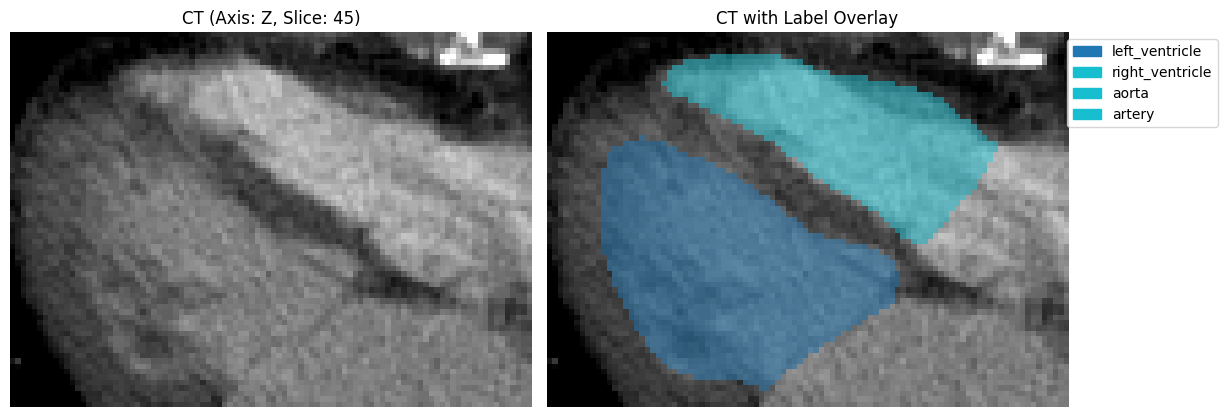

In [104]:
# # Ablakozás (windowing) a CT értékeken, ami a notebook-ban is javítja a sheetness eredményét
cropped_ct_windowed = np.clip(cropped_ct_array, -100, 600)

visualization.plot_slice_with_labels(cropped_ct_windowed, cropped_relevant_labels_dic, axis='z', save_path=os.path.join(output_dir, 'windowed_ct_overlay.png'))



In [105]:
def multiscale_sheetness_3d(image: np.ndarray, sigmas: list, alpha=0.5, beta=0.5, c=None, mask: np.ndarray = None) -> np.ndarray:
    """
    Többskálás szűrés (sheetness) a teljes képen.
    """
    if c is None:
        c = filter.calculate_c_in_skeleton(image, mask, sigmas)
        #print(f"Használt c érték a sheetness képlethez: {c}")

    max_scores = np.zeros_like(image, dtype=np.float32)
    mask_coords = np.nonzero(mask)
    for s in sigmas:
        #print(f" -> Számítás sigma = {s} skálán (sheetness)...")
        
        H = filter.compute_hessian_at_coords(image, mask_coords, s)

        # Sajátértékek kiszámítása (a sajátvektorokat nem kérjük le)
        eigvals = np.linalg.eigvalsh(H)

        abs_eigvals = np.abs(eigvals)
        sort_indices = np.argsort(abs_eigvals, axis=-1)

        l1 = np.take_along_axis(eigvals, sort_indices[..., 0:1], axis=-1)[..., 0]
        l2 = np.take_along_axis(eigvals, sort_indices[..., 1:2], axis=-1)[..., 0]
        l3 = np.take_along_axis(eigvals, sort_indices[..., 2:3], axis=-1)[..., 0]

        scores = filter.calculate_sheetness_3d(l1, l2, l3, alpha, beta, c)

        # Frissítjük a maximumokat
        current_max = max_scores[mask_coords]          # (N,)
        better = scores > current_max                  # (N,) bool

        # Csak a jobb értékű pontokat frissítjük a 3D tömbben
        better_coords = tuple(c[better] for c in mask_coords)
        max_scores[better_coords] = scores[better]

    #print("\nSzűrés kész! Maximális válaszok kigyűjtve.")
    return max_scores

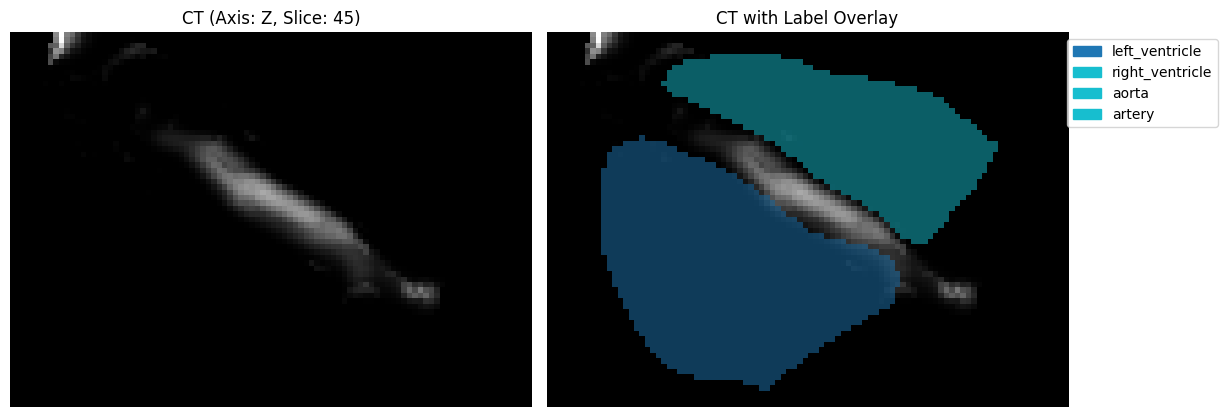

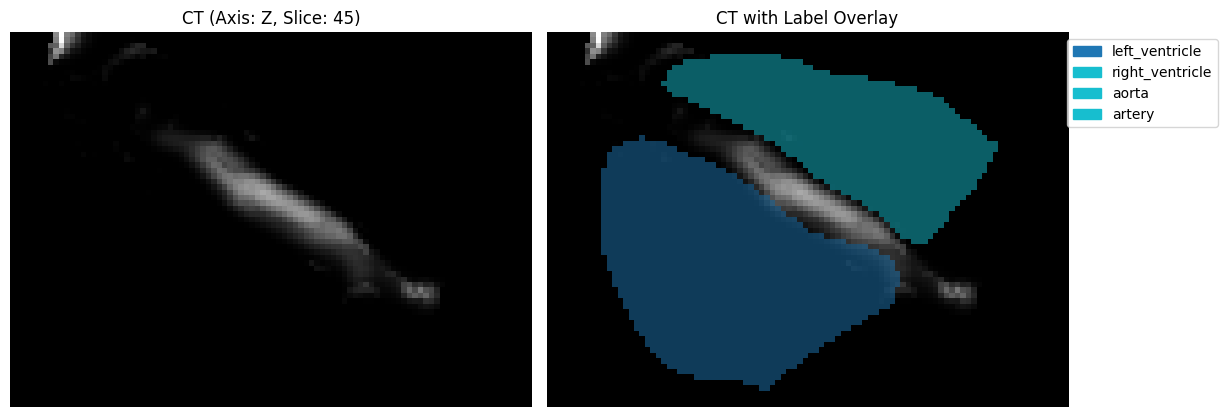

Kép sikeresen elmentve ide: output\ImageCHD_dataset\ct_1178_iso\final_sheetness.nii.gz


In [106]:
#     # Filter lefuttatása a windowolt CT-n dinamikusan számolt 'c' konstanssal 
max_scores = multiscale_sheetness_3d(cropped_ct_array, sigmas=[1.0, 2.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0], alpha=0.15, beta=0.2, mask=septum_mask)
visualization.plot_slice_with_labels(max_scores, cropped_relevant_labels_dic, axis='z', save_path=os.path.join(output_dir, 'sheetness_overlay.png'))

#     # A levágott végleges tiszta bal kamra (az aortalefolyás nélkül)
#combined_mask = np.logical_and(np.logical_and(cropped_cut_mask_aorta, cropped_cut_mask_artery), septum_mask)
cropped_sheetness = np.where(septum_mask, max_scores, 0)

visualization.plot_slice_with_labels(cropped_sheetness, cropped_relevant_labels_dic, axis='z', save_path=os.path.join(output_dir, 'final_sheetness_overlay.png'))

# Visszatesszük a kivágott sheetness eredményt a teljes CT méretű tömbbe
sheetness_full = np.zeros_like(ct_array, dtype=np.float32)
z_idx, y_idx, x_idx = np.nonzero(roi_mask)
if len(z_idx) > 0:
        z_min, z_max = max(0, z_idx.min()), min(ct_array.shape[0], z_idx.max() + 1)
        y_min, y_max = max(0, y_idx.min()), min(ct_array.shape[1], y_idx.max() + 1)
        x_min, x_max = max(0, x_idx.min()), min(ct_array.shape[2], x_idx.max() + 1)
        sheetness_full[z_min:z_max, y_min:y_max, x_min:x_max] = cropped_sheetness

output.save_array_as_image(sheetness_full, ct_image, os.path.join(output_dir, 'final_sheetness.nii.gz'))

In [ ]:
z_idx, y_idx, x_idx = np.nonzero(roi_mask)

z_min: int = max(0, z_idx.min())
z_max: int = min(ct_array.shape[0], z_idx.max() + 1)

y_min: int = max(0, y_idx.min())
y_max: int = min(ct_array.shape[1], y_idx.max() + 1)

x_min: int = max(0, x_idx.min())
x_max: int = min(ct_array.shape[2], x_idx.max() + 1)
    
# CT kivágása
cropped_intersection = intersection[z_min:z_max, y_min:y_max, x_min:x_max]

visualization.plot_slice_with_labels(cropped_sheetness, labels={'intersection': cropped_intersection}, slice_idx=45, axis='z', save_path=os.path.join(output_dir, 'final_sheetness_overlay.png'))

IndexError: boolean index did not match indexed array along axis 0; size of axis is 90 but size of corresponding boolean axis is 84

In [ ]:
#1178-as ct kamra összeéréseinek a kimentése
from scipy import ndimage


dataset_dir, cfg = config.load_config("ImageCHD_dataset")
image_path, label_path = input.get_input_paths(dataset_dir)
print(f"\n--- Feldolgozás alatt: {os.path.basename(image_path)} ---")
ct_image, ct_array, _, label_array = input.load_ct_and_label(image_path, label_path)

output.set_reference(ct_image)

relevant_labels_dic = label.extract_labels(label_array, cfg)

dist_to_1 = ndimage.distance_transform_edt(~relevant_labels_dic['left_ventricle'],)
dist_to_2 = ndimage.distance_transform_edt(~relevant_labels_dic['right_ventricle'])
    
    # A septum az a régió, ahol mindkét kamrától legfeljebb 'max_distance_mm' távolságra vagyunk
    # Mivel izotróp a rácsunk (1x1x1 mm), a távolság közvetlenül millimétert jelent!
intersection = (dist_to_1 <= 1) & (dist_to_2 <= 1)


output_dir = output.derive_output_dir(image_path, "ImageCHD_dataset")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

output.save_image(intersection.astype(np.uint8), os.path.join(output_dir, 'septum_intersection.nii.gz'))

visualization.plot_slice_with_labels(ct_array, relevant_labels_dic, axis='z', save_path=os.path.join(output_dir, 'septum_intersection_overlay.png'))

In [2]:
!pip install TotalSegmentator

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
!totalseg_set_license -l aca_A78TO3TZ2AQ412

An Exception occurred: HTTPSConnectionPool(host='backend.totalsegmentator.com', port=443): Max retries exceeded with url: /is_valid_license_number (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1032)')))
ERROR: Invalid license number. Please check your license number or contact support.


In [6]:
import json
from pathlib import Path
import totalsegmentator.config as ts_config

# 1. Config fájl írása
config_dir = Path.home() / ".totalsegmentator"
config_dir.mkdir(parents=True, exist_ok=True)
with open(config_dir / "config.json", "w") as f:
    json.dump({"license_number": "aca_A78TO3TZ2AQ412"}, f)

# 2. License ellenőrző függvény patch-elése – szerver nélkül
def always_valid(license_number):
    return True

def always_valid_status(license_number):
    return "valid_license", "ok"

# A függvény neve verziónként változhat – mindkettőt patch-eljük
for fn_name in ["is_valid_license", "check_license", "get_license_status"]:
    if hasattr(ts_config, fn_name):
        setattr(ts_config, fn_name, always_valid)
        print(f"Patch-elve: ts_config.{fn_name}")

# 3. A python_api modulban is patch-eljük
import totalsegmentator.python_api as ts_api
for fn_name in ["is_valid_license", "check_license", "get_license_status"]:
    if hasattr(ts_api, fn_name):
        setattr(ts_api, fn_name, always_valid)
        print(f"Patch-elve: ts_api.{fn_name}")

print("Patch kész, futtatás...")

# 4. Szegmentáció
from totalsegmentator.python_api import totalsegmentator

totalsegmentator(
    input=ct_files[0],
    output="/kaggle/working/test_out",
    task="heartchambers_highres",
    quiet=False,
)

Patch-elve: ts_config.is_valid_license
Patch kész, futtatás...


NameError: name 'ct_files' is not defined

In [5]:
import requests

# SSL ellenőrzés kikapcsolásával próbáljuk elérni a szervert
try:
    r = requests.get(
        "https://backend.totalsegmentator.com/is_valid_license_number",
        params={"license_number": "aca_A78TO3TZ2AQ412"},
        verify=False,   # SSL bypass
        timeout=10
    )
    print(f"Státusz: {r.status_code}")
    print(f"Válasz: {r.text}")
except Exception as e:
    print(f"Még SSL bypass-szal sem megy: {e}")

Még SSL bypass-szal sem megy: HTTPSConnectionPool(host='backend.totalsegmentator.com', port=443): Max retries exceeded with url: /is_valid_license_number?license_number=aca_A78TO3TZ2AQ412 (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1032)')))


In [ ]:
!TotalSegmentator -d --task heartchambers_highres
# Becsomagoljuk az egész modellsúly mappát
!zip -r totalseg_weights.zip 

In [13]:
import nibabel as nib
import numpy as np
import os

# A különálló fájlok listája és a hozzájuk rendelni kívánt egész számok (label ID-k)
# Érdemes a struktúráknak logikus, egyedi azonosítókat adni.

basedir = "ImageCHD_dataset\\resampled\\ct_1178"

files_to_combine = {
    'aorta.nii.gz': 6,
    'pulmonary_artery.nii.gz': 7,
    'heart_ventricle_left.nii.gz': 1,
    'heart_ventricle_right.nii.gz': 2
}

# Referencia kép betöltése (az eredeti izotróp CT kép vagy az egyik maszk)
# Erre azért van szükség, hogy a térbeli orientáció (affine) és a fejléc (header) megmaradjon.
ref_img = nib.load(os.path.join(basedir, 'aorta.nii.gz')) 

# Létrehozunk egy üres (csupa nulla) 3D mátrixot, ami megegyezik a CT kép dimenzióival.
# A uint8 adattípus memóriatakarékos és elegendő, ha <256 osztályod van.
combined_data = np.zeros(ref_img.shape, dtype=np.uint8)

# Végigmegyünk a fájlokon, és rávetítjük őket a közös mátrixra
for filename, label_value in files_to_combine.items():
    img = nib.load(os.path.join(basedir, filename))
    data = img.get_fdata()
    
    # Ahol az aktuális maszk értéke nagyobb mint 0 (ahol a struktúra jelen van),
    # oda beírjuk az általunk megadott label ID-t.
    combined_data[data > 0] = label_value

# Új NIfTI objektum létrehozása az egyesített adatokból és a referencia térbeli adataiból
combined_img = nib.Nifti1Image(combined_data, ref_img.affine, ref_img.header)

# Az eredmény elmentése
nib.save(combined_img, os.path.join(basedir, 'combined_multi_label.nii.gz'))
print("Az egyesített label fájl sikeresen létrejött!")

Az egyesített label fájl sikeresen létrejött!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

z_mid = ct_array.shape[0] // 2
y_mid = ct_array.shape[1] // 2
x_mid = ct_array.shape[2] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
flips = [None, 1, 2]  # no flip, Y flip, X flip
titles = ["Eredeti", "Y flip (axis=1)", "X flip (axis=2)"]

for i, (flip, title) in enumerate(zip(flips, titles)):
    arr = np.flip(ct_array, axis=flip) if flip else ct_array
    
    axes[0, i].imshow(arr[z_mid], cmap='gray', origin='upper')
    axes[0, i].set_title(f"Axial – {title}")
    axes[0, i].set_xlabel("← jobb | bal →")
    axes[0, i].set_ylabel("↑ elöl | hátul ↓")
    
    axes[1, i].imshow(arr[:, :, x_mid], cmap='gray', origin='upper')
    axes[1, i].set_title(f"Sagittal – {title}")
    axes[1, i].set_xlabel("← elöl | hátul →")
    axes[1, i].set_ylabel("↑ inf | sup ↓")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Fájl betöltése
data = np.load("training_data.npz")
X = data['X']
y = data['y']
ids = data['ids']

# 2. Alapvető dimenziók ellenőrzése
print("--- ADATHALMAZ ELLENŐRZÉSE ---")
print(f"Bemeneti jellemzők (X) alakja: {X.shape}  -> (Minták, Szekvencia_hossz, Jellemzők)")
print(f"Célváltozó (y) alakja: {y.shape} -> (Minták, Szekvencia_hossz)")
print(f"Beteg azonosítók (ids) alakja: {ids.shape}")
print(f"Első 5 azonosító: {ids[:5]}")

# 3. Vizsgáljunk meg egy konkrét esetet! 
# Írd át a sample_idx-et, ha másik beteget akarsz megnézni (0-tól 175-ig)
sample_idx = 0  
ct_id = ids[sample_idx]

print(f"\n--- VIZUALIZÁCIÓ: {ct_id} ---")

# Kinyerjük a kiválasztott beteg jellemzőit
# A feature_cols sorrendje a generáló scriptben ez volt: 
# ['Tubeness', 'Radius', 'L1', 'L2', 'L3', 'Norm_Z', 'Norm_Y', 'Norm_X']
tubeness = X[sample_idx, :, 0]
radius = X[sample_idx, :, 1]
norm_z = X[sample_idx, :, 5]

target_y = y[sample_idx, :]

# 4. Rajzolás
plt.figure(figsize=(12, 6))

# Rajzoljuk a jellemzőket (a Radius-t leosztjuk 10-zel, hogy beférjen a 0-1 skálára vizuálisan)
plt.plot(tubeness, label='Tubeness (Csőszerűség)', color='blue', linewidth=2)
plt.plot(radius / 10.0, label='Radius (Sugár / 10)', color='green', linestyle=':')
plt.plot(norm_z, label='Norm_Z', color='orange', alpha=0.7)

# Rajzoljuk a CÉLVÁLTOZÓT (A te Gauss-görbédet) vastag piros szaggatott vonallal
plt.plot(target_y, label='TARGET (Célváltozó)', color='red', linewidth=3, linestyle='--')

plt.title(f"Tanítóadat ellenőrzése: {ct_id}")
plt.xlabel("Szekvencia index (0-99)")
plt.ylabel("Skálázott értékek")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os
import numpy as np
import scipy.ndimage as ndimage
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
import SimpleITK as sitk


def get_shortest_path_between_farest_points(skeleton : np.ndarray) -> np.ndarray:
    z,y,x = np.nonzero(skeleton)
    skeleton_neighbors = {}

    for i in range(len(z)):
        z_coord, y_coord, x_coord = z[i], y[i], x[i]
        neighbors = []
        
        for j in range(len(z)):
            if i == j:
                continue
            z_neighbor, y_neighbor, x_neighbor = z[j], y[j], x[j]
            dx = abs(x_neighbor - x_coord)
            dy = abs(y_neighbor - y_coord)
            dz = abs(z_neighbor - z_coord)
            if dx <= 1 and dy <= 1 and dz <= 1:
                neighbors.append((z_neighbor, y_neighbor, x_neighbor))

        skeleton_neighbors[(z_coord, y_coord, x_coord)] = neighbors

    farest_points = ()
    longest_distance = 0.0
    longest_distance_idx = (0, 0)

    for i in range(len(z)):
        for j in range(i + 1, len(z)):
            point1 = (z[i], y[i], x[i])
            point2 = (z[j], y[j], x[j])
            distance = np.sqrt((point1[0] - point2[0]) ** 2 + (point1[1] - point2[1]) ** 2 + (point1[2] - point2[2]) ** 2)
            
            if distance > longest_distance:
                longest_distance = distance
                longest_distance_idx = (i, j)

    farest_points = (longest_distance, (z[longest_distance_idx[0]], y[longest_distance_idx[0]], x[longest_distance_idx[0]]), (z[longest_distance_idx[1]], y[longest_distance_idx[1]], x[longest_distance_idx[1]]))

    shortest_path = find_shortest_path(farest_points[1], farest_points[2], skeleton_neighbors)
    return shortest_path

def find_shortest_path(start_point : tuple, end_point : tuple, skeleton_neighbors : dict) -> np.ndarray:
    from collections import deque
    visited = set()
    queue = deque([(start_point, [start_point])])  # (current_point, path_to_current)
    
    while queue:
        current_point, path = queue.popleft()
        
        if current_point == end_point:
            return np.array(path)
        
        if current_point in visited:
            continue
        
        visited.add(current_point)
        
        for neighbor in skeleton_neighbors.get(current_point, []):
            if neighbor not in visited:
                queue.append((neighbor, path + [neighbor]))
    
    return np.array([])  # Nincs út a két pont között

def compute_hessian_at_coords(image: np.ndarray, coords: tuple, sigma: float) -> np.ndarray:
    """
    Kiszámolja a Hesse-mátrixot a megadott koordinátákra egy adott skálán (sigma).
    Kimenete: (Pontok_száma, 3, 3) alakú numpy tömb.
    """
    sz, sy, sx = coords
    num_points = len(sz)

    # A deriváltakat a teljes képen számoljuk a Gauss elmosás miatt
    s2 = sigma**2
    Dzz = ndimage.gaussian_filter(image, sigma, order=[2, 0, 0]) * s2
    Dyy = ndimage.gaussian_filter(image, sigma, order=[0, 2, 0]) * s2
    Dxx = ndimage.gaussian_filter(image, sigma, order=[0, 0, 2]) * s2
    Dzy = ndimage.gaussian_filter(image, sigma, order=[1, 1, 0]) * s2
    Dzx = ndimage.gaussian_filter(image, sigma, order=[1, 0, 1]) * s2
    Dyx = ndimage.gaussian_filter(image, sigma, order=[0, 1, 1]) * s2

    # Hesse-mátrix építése CSAK a koordináták pontjainál
    H_skel = np.zeros((num_points, 3, 3), dtype=np.float32)
    H_skel[:, 0, 0] = Dzz[sz, sy, sx]
    H_skel[:, 0, 1] = Dzy[sz, sy, sx]
    H_skel[:, 0, 2] = Dzx[sz, sy, sx]
    H_skel[:, 1, 0] = Dzy[sz, sy, sx]
    H_skel[:, 1, 1] = Dyy[sz, sy, sx]
    H_skel[:, 1, 2] = Dyx[sz, sy, sx]
    H_skel[:, 2, 0] = Dzx[sz, sy, sx]
    H_skel[:, 2, 1] = Dyx[sz, sy, sx]
    H_skel[:, 2, 2] = Dxx[sz, sy, sx]

    return H_skel

def calculate_c_in_skeleton(binary: np.ndarray, skeleton: np.ndarray, sigmas: list) -> float:
    """
    Kiszámolja a c paramétert a csőszerűséghez képlethez a kép intenzitásának statisztikái alapján.
    """
    global_max_S = 0
    skeleton_coords = np.nonzero(skeleton)
    for s in sigmas:
        print("Mátrix építés és sajátérték-számítás...")
        
        H_skel = compute_hessian_at_coords(binary, skeleton_coords, s)
        eigvals = np.linalg.eigvalsh(H_skel)

        # S = H abs értékének kiszámítása
        S = np.sqrt(np.sum(eigvals**2, axis=-1))
        
        # A zaj kiszűrése és a max/percentilis keresése
        valid_S = S[S > 1e-6]
        if len(valid_S) > 0:
            current_max = np.percentile(valid_S, 99)
        else:
            current_max = 0.0
        
        print(f"Skála: {s}, 99%-os percentilis S: {current_max}")
            
        if current_max > global_max_S:
            global_max_S = current_max

    c = global_max_S / 1.5
    c = max(c, 1e-6)
    return c

def evaluate_tubeness_on_skeleton(l1: np.ndarray, l2: np.ndarray, l3: np.ndarray, alpha: float, beta: float, c: float) -> np.ndarray:
    eps = 1e-10
        
    abs_l1, abs_l2, abs_l3 = np.abs(l1), np.abs(l2), np.abs(l3)

    R_plate = abs_l2 / (abs_l3 + eps)
    R_blob = abs_l1 / (np.sqrt(abs_l2 * abs_l3) + eps)
    S = np.sqrt(l1**2 + l2**2 + l3**2)

    scores = (1 - np.exp(-(R_plate**2) / (2 * alpha**2))) * \
             np.exp(-(R_blob**2) / (2 * beta**2)) * \
             (1 - np.exp(-(S**2) / (2 * c**2)))
             
    scores[(l3 > -0.1) | (l2 > -0.05)] = 0
    # debug print
    for i in range(len(scores)):
        print(f"Pont {i}: l1={l1[i]:.4f}, l2={l2[i]:.4f}, l3={l3[i]:.4f}, R_plate={R_plate[i]:.4f}, R_blob={R_blob[i]:.4f}, S={S[i]:.4f}, score={scores[i]:.4f}")
            
    return np.nan_to_num(scores)

def multiscale_tubeness_3d(image: np.ndarray, skeleton: np.ndarray, sigmas: list, alpha=0.5, beta=0.1, c=None) -> dict:
    """
    Többskálás szűrés (tubeness) a skeleton pontjain.
    """
    if c is None:
        c = calculate_c_in_skeleton(image, skeleton, sigmas)
        print(f"Használt c érték a tubeness képlethez: {c}")

    max_scores = np.zeros_like(image, dtype=np.float32)
    best_eigenvectors = np.zeros(image.shape + (3,), dtype=np.float32)

    coords = np.nonzero(skeleton)
    sz, sy, sx = coords
    num_points = len(sz)
    print(f"Összesen {num_points} darab skeleton pontot vizsgálunk.")

    for s in sigmas:
        print(f" -> Számítás sigma = {s} skálán (tubeness)...")
        
        H = compute_hessian_at_coords(image, coords, s)

        # Sajátértékek és sajátvektorok kiszámítása
        eigvals, eigvecs = np.linalg.eigh(H)

        abs_eigvals = np.abs(eigvals)
        sort_indices = np.argsort(abs_eigvals, axis=-1)

        l1 = np.take_along_axis(eigvals, sort_indices[..., 0:1], axis=-1)[..., 0]
        l2 = np.take_along_axis(eigvals, sort_indices[..., 1:2], axis=-1)[..., 0]
        l3 = np.take_along_axis(eigvals, sort_indices[..., 2:3], axis=-1)[..., 0]

        # L1 sajátvektor (a vágósík normálvektora)
        u1_indices = sort_indices[..., 0]
        # U1 vektor kiválasztása, id_repeated kell a megfelelő dimenziószám miatt
        idx_repeated = np.repeat(np.expand_dims(u1_indices, axis=(-2, -1)), 3, axis=-2)
        u1_current = np.take_along_axis(eigvecs, idx_repeated, axis=-1)[..., 0]

        scores = evaluate_tubeness_on_skeleton(l1, l2, l3, alpha, beta, c)

        # Visszamappelés a teljes 3D képre
        scores_full = np.zeros_like(image, dtype=np.float32)
        scores_full[sz, sy, sx] = scores
        scores = scores_full

        u1_full = np.zeros(image.shape + (3,), dtype=np.float32)
        u1_full[sz, sy, sx, :] = u1_current
        u1_current = u1_full

        # Frissítjük a maximumokat
        better_mask = scores > max_scores
        max_scores[better_mask] = scores[better_mask]
        best_eigenvectors[better_mask] = u1_current[better_mask]

    print("\nSzűrés kész! Maximális válaszok kigyűjtve.")
    return {
        'scores': max_scores,
        'eigenvectors': best_eigenvectors
    }


def get_max_tubeness_indices(scores_on_skel, eigenvectors_on_skel, sz, sy, sx) -> tuple[tuple[int, int, int], np.ndarray]:
    if len(scores_on_skel) == 0:
        return (-1, -1, -1), np.array([0.0, 0.0, 0.0])
    
    max_idx = int(np.argmax(scores_on_skel))
    max_score = scores_on_skel[max_idx]
    
    p_z, p_y, p_x = int(sz[max_idx]), int(sy[max_idx]), int(sx[max_idx])
    normal_vector: np.ndarray = eigenvectors_on_skel[max_idx]
    
    print(f"Megtalálva: Z: {p_z}, {max_score}")
    print(f"Vágási pont megtalálva: Z={p_z}, Y={p_y}, X={p_x}, Normál vektor: {normal_vector}")
    return (p_z, p_y, p_x), normal_vector

In [ ]:
def get_smoothed(scale: int, ventricle_label: np.ndarray, tube_label: np.ndarray) -> np.ndarray:
    distance = 1 * scale
    iterations = 5
    
    smoothed_ventricle = ndimage.binary_dilation(ventricle_label, iterations=iterations)
    smoothed_ventricle = ndimage.binary_erosion(smoothed_ventricle, iterations=iterations)
    
    print(f"Skála: {scale}, Távolság a kamrához és csőhöz: {distance}, Iterációk száma: {iterations}")
      
    dist_to_ventricle = distance_transform_edt(~ventricle_label)
    
    tubular_tube = (dist_to_ventricle < distance) & tube_label
    
    unio = smoothed_ventricle | tubular_tube
    
    smoothed = ndimage.binary_dilation(unio, iterations=3)
    smoothed = ndimage.binary_erosion(smoothed, iterations=3)
    
    return smoothed.astype(np.uint8)


def get_dummy_plane(ventricle_label: np.ndarray, tube_label: np.ndarray, ct_array: np.ndarray = None, ct_image: sitk.Image = None, out_dir: str = None, ventricle_type: str = None, tube_type: str = None) -> tuple[np.ndarray, np.ndarray]:
    """
    Keres egy vágósíkot a kamra és a cső (pl. aorta) között, amely elválasztja a kettőt.
    
    Args:
        ventricle_label: a kamra maszkja (pl. bal kamra)
        tube_label: a cső maszkja (pl. aorta)
        ct_array: A CT kép a vizualizációhoz (opcionális)
        ct_image: A CT kép a vizualizációhoz (opcionális)
        out_dir: A kimeneti könyvtár elérési útvonala (opcionális)
        ventricle_type: A kamra típusa (pl. bal kamra)
        tube_type: A cső típusa (pl. aorta)
    Returns:
        visual_plane_mask: A sík megjelenítéshez használt maszkja (néhány voxel vastag).
        half_space_mask: Egy bináris maszk, amellyel vágni lehet a kamrát 
                         (True a sík "alatt/mögött", False az eldobandó részen).
    """
    out_dir += f"_{tube_type}" if tube_type else ""
    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)
        
    scale = 0.5
    while True:
        smoothed = get_smoothed(scale=scale, ventricle_label=ventricle_label, tube_label=tube_label)
        skeleton = skeletonize(smoothed)
        
        # Szigetek keresése 26-os szomszédsággal
        struct_26 = ndimage.generate_binary_structure(3, 3)
        labeled_skeleton, num_features = ndimage.label(skeleton, structure=struct_26)
        
        if num_features > 0:
            # Legnagyobb sziget megkeresése (a bincount 0. eleme a háttér, azt kihagyjuk)
            sizes = np.bincount(labeled_skeleton.flat)[1:]
            largest_label = np.argmax(sizes) + 1
            main_skeleton = (labeled_skeleton == largest_label)
            
            main_path = get_shortest_path_between_farest_points(main_skeleton)
            
            main_path_mask = np.zeros_like(main_skeleton, dtype=np.uint8)
            if len(main_path) > 0:
                main_path_mask[tuple(main_path.T)] = 1
            print(f"Fő útvonal mérete: {main_path_mask.sum()} voxel.")
            
            # a main path nem csak a kamrában, de a csőben is megy, akkor az jó
            if tube_label[main_path_mask.astype(bool)].sum() > 3:
                
                print(f"Fő útvonal mérete: {main_path_mask.sum()} voxel.")
                print(f"Megfelelő fő útvonal találva a kamra és cső között.{tube_label[main_path_mask.astype(bool)].sum()} ")
                
                dilated_skeleton = ndimage.binary_dilation(main_skeleton, iterations=1)
                output.save_image(dilated_skeleton.astype(np.uint8), os.path.join(out_dir, "dilated_main_skeleton.nii.gz"))
                output.save_image(smoothed.astype(np.uint8), os.path.join(out_dir, "smoothed.nii.gz"))
                dilated_main_path = ndimage.binary_dilation(main_path_mask, iterations=1)
                output.save_image(dilated_main_path.astype(np.uint8), os.path.join(out_dir, "dilated_main_path.nii.gz"))
                break
            else:
                scale += 1.0
        else:
            scale += 1.5
            
    # Region of Interest meghatározása az átmenet kereséséhez, a fő vonal 10%-a
    cut_len = int(len(main_path) * 0.1) 
    bottleneck_path = main_path[:cut_len]

    # A binary_mask lehet az 'interesting_region', vagy az aorta/kamra eredeti uniója is.
    # Fontos, hogy ez az a vastag maszk legyen, aminek a falától a távolságot mérjük!
    distance_map = distance_transform_edt(smoothed.astype(bool))
    
    if len(bottleneck_path) > 0:
        radii_in_voxels = distance_map[tuple(bottleneck_path.T)] # át kell alakítani koordinátákká
    else:
        radii_in_voxels = []

    if len(radii_in_voxels) > 0:
        mean_r = np.mean(radii_in_voxels)
        filtered_radii = radii_in_voxels[radii_in_voxels < mean_r]
        bottleneck_radius = np.median(filtered_radii) if len(filtered_radii) > 0 else np.median(radii_in_voxels)
        min_r = np.min(radii_in_voxels)
        max_r = np.max(radii_in_voxels)
        median_r = np.median(radii_in_voxels)
        
        
        print(f"\nAz ér/kamra szakasz sugarai a skeleton mentén (voxelben):")
        print(f"  Minimum sugár: {min_r:.2f}")
        print(f"  Maximum sugár: {max_r:.2f}")
        print(f"  Átlagos sugár: {mean_r:.2f}")
        
        # Dinamikus sigmák
        dynamic_sigmas = np.linspace(min(min_r, 1.0), max(max_r, 5.0), num=10).tolist()
        print(f"  --> Automatikusan javasolt szigmák a szűrőhöz: {dynamic_sigmas}")
    else:
        print("Nem található skeleton pont a távolságok kinyeréséhez.")
        # Ha egyáltalán nincs érték, adjunk egy biztonságos fallback listát!
        dynamic_sigmas = [1.0, 2.0, 3.0,  4.0, 5.0, 6.0]

    z_idx, y_idx, x_idx = np.nonzero(smoothed)

    z_min: int = max(0, z_idx.min())
    z_max: int = min(smoothed.shape[0], z_idx.max() + 1)
        
    y_min: int = max(0, y_idx.min())
    y_max: int = min(smoothed.shape[1], y_idx.max() + 1)
        
    x_min: int = max(0, x_idx.min())
    x_max: int = min(smoothed.shape[2], x_idx.max() + 1)
    
    # CT kivágása
    smoothed_cropped = smoothed[z_min:z_max, y_min:y_max, x_min:x_max]
    skeleton_cropped = main_skeleton[z_min:z_max, y_min:y_max, x_min:x_max]
    main_path_cropped = main_path_mask[z_min:z_max, y_min:y_max, x_min:x_max]
    
    # A fő vonal alsó 20%-át levágjuk, hogy ez ne zavarjon
    cut_len = int(len(main_path) * 0.2) 
    interesting_path = main_path[cut_len:]
    
    # EREDETI MÉRETŰ maszkot készítünk, beleírjuk az 1-eseket
    interesting_mask_full = np.zeros_like(main_skeleton, dtype=np.uint8)
    if len(interesting_path) > 0:
        interesting_mask_full[tuple(interesting_path.T)] = 1
        
    # Majd ezt VÁGJUK KI a kisebb bounding boxra
    interesting_mask_cropped = interesting_mask_full[z_min:z_max, y_min:y_max, x_min:x_max]
            
    print(f"Kivágott doboz mérete: Z:{z_max-z_min}, Y:{y_max-y_min}, X:{x_max-x_min}")
    tubeness_result = multiscale_tubeness_3d(
            image=smoothed_cropped.astype(np.float32), 
            sigmas=dynamic_sigmas,
            skeleton=interesting_mask_cropped, 
            alpha=0.25, # annyira nem fontos, hogy a cső két kersztmetszete hasonló legyen 
            beta=1.0
        )
    
    scores_cropped = tubeness_result['scores']
    eigenvectors_cropped = tubeness_result['eigenvectors']
    
    # Pontosan azon a maszkon keressük a nem-nulla értékeket, amin a tubeness-t lefuttattuk
    z_skel, y_skel, x_skel = np.nonzero(interesting_mask_cropped) 
    
    # Kinyerjük az értékeket pontosan a skeleton pontjain
    scores_on_skel = scores_cropped[z_skel, y_skel, x_skel]
    eigenvectors_on_skel = eigenvectors_cropped[z_skel, y_skel, x_skel]

    # Maximális csőszerűségi értékek vizualizálása
    # x : z. index
    # y: csőszerűsége a maximálisnak ezen z índexen 

    max_scores_per_z = {}
    for z, score in zip(z_skel, scores_on_skel):
        max_scores_per_z[z] = max(max_scores_per_z.get(z, 0), score)

    # Plotolás
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(list(max_scores_per_z.keys()), list(max_scores_per_z.values()), marker='o')
    plt.title('Maximális és átlagos csőszerűségi értékek a skeleton mentén Z szerint')
    plt.xlabel('Z index')
    plt.ylabel('Csőszerűségi érték')
    plt.grid()
    plt.savefig(os.path.join(out_dir, "max_tubeness_along_skeleton.png"))
    plt.show()
    
    #output.save_image(scores_on_skel, os.path.join(out_dir, "scores_on_skeleton.nii.gz"))

    (p_z, p_y, p_x), normal_vector = get_max_tubeness_indices(
            scores_on_skel=scores_on_skel,
            eigenvectors_on_skel=eigenvectors_on_skel,
            sz=z_skel,
            sy=y_skel,
            sx=x_skel,
        )

    # --- SÍK GENERÁLÁSA ---
    n_z, n_y, n_x = normal_vector[0], normal_vector[1], normal_vector[2]

    # Eredeti, nem vágott koordinátarendszerbe való visszaállítás
    p_z += z_min
    p_y += y_min
    p_x += x_min

    print(f"Vágási pont megtalálva: Z={p_z}, Y={p_y}, X={p_x}, Normál vektor: {normal_vector}")

    shape = ventricle_label.shape
    Z, Y, X = np.ogrid[0:shape[0], 0:shape[1], 0:shape[2]]
        
    plane_equation = n_z * (Z - p_z) + n_y * (Y - p_y) + n_x * (X - p_x)

    visual_plane_mask = np.abs(plane_equation) <= 2.0

    # Irány korrigálása, hogy a Z tengely (fej felé) vágjon lefelé
    if n_z > 0:
        plane_equation = -plane_equation

    half_space_mask = plane_equation > 0 
    # vizualizációs ellenőrzéshez
    print(f"Vágási pont megtalálva: Z={p_z}, Y={p_y}, X={p_x}")
    print("A vágási sík a cső és a kamra között")
    save_path_3d = out_dir + f"/cutting_plane_overlay_3d_{tube_type}.png" if out_dir else None
    visualization.plot_3d_slices_with_labels(ct_array, {tube_type : tube_label, ventricle_type : ventricle_label, 'cutting_plane': visual_plane_mask}, slice_indices=(z_center, y_center, x_center), save_path=save_path_3d)

    return visual_plane_mask, half_space_mask

In [ ]:
import argparse
import os
import numpy as np
import SimpleITK as sitk

from soveny import tube_BB
from soveny import config
from soveny import input
from soveny import label
from soveny import ventircles_BB
from soveny import visualization
from soveny import septum_BB
from soveny import filter
from soveny import output
from soveny import resample

In [ ]:
dataset = "ImageCHD_dataset" 
dataset_dir, cfg = config.load_config(dataset)

In [ ]:
dataset_dir = os.path.join(dataset_dir, "preprocessed")  # Resampled könyvtár használata most az ImageCHD_dataset-ben, ahol már izotrópra van resample-elve a CT és a label is.

image_path, label_path = input.get_input_paths(dataset_dir)
ct_image, ct_array, label_image, label_array = input.load_ct_and_label(image_path, label_path)

In [ ]:
output_dir = output.derive_output_dir(image_path, dataset)
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

In [ ]:

relevant_labels_dic = label.extract_labels(label_array, cfg)

    
roi_mask = relevant_labels_dic['left_ventricle'] | relevant_labels_dic['right_ventricle']
    
cropped_ct_array, cropped_relevant_labels_dic = ventircles_BB.crop_to_roi(
        ct_array, 
        relevant_labels_dic, 
        roi_mask
)
    
visualization.plot_slice_with_labels(cropped_ct_array, cropped_relevant_labels_dic, axis='z', save_path=os.path.join(output_dir, 'ventricles_overlay.png'))
    
septum_mask = septum_BB.get_septum_by_distance(
        cropped_relevant_labels_dic['left_ventricle'],
        cropped_relevant_labels_dic['right_ventricle'],
        max_distance_mm=12
)
    
visualization.plot_slice_with_labels(cropped_ct_array, {'septum': septum_mask,}, axis='z', save_path=os.path.join(output_dir, 'septum_overlay.png'))


In [ ]:
visual_plane_aorta, cut_mask_aorta = get_dummy_plane(
        ventricle_label=relevant_labels_dic['left_ventricle'],
        tube_label=relevant_labels_dic['aorta'],
        ct_array=ct_array,
        ct_image=ct_image,
        out_dir=os.path.join(output_dir, "aorta_cutting_plane"),
        tube_type='aorta',
        ventricle_type='left_ventricle'
    )

In [ ]:
visual_plane_artery, cut_mask_artery = get_dummy_plane(
       ventricle_label=relevant_labels_dic['right_ventricle'],
        tube_label=relevant_labels_dic['artery'],
        ct_array=ct_array,
        ct_image=ct_image,
        out_dir=os.path.join(output_dir, "artery_cutting_plane"),
        tube_type='artery',
        ventricle_type='right_ventricle'
)

In [ ]:
cropped_cut_mask_aorta = ventircles_BB.get_cropped_array(cut_mask_aorta, roi_mask)
cropped_cut_mask_artery = ventircles_BB.get_cropped_array(cut_mask_artery, roi_mask)
    
visualization.plot_slice_with_labels(ct_array, {'aorta_cut': cut_mask_aorta, 'artery_cut': cut_mask_artery}, axis='z', save_path=os.path.join(output_dir, 'cut_masks_overlay.png'))
    

In [ ]:
   # Ablakozás (windowing) a CT értékeken, ami a notebook-ban is javítja a sheetness eredményét
cropped_ct_windowed = np.clip(cropped_ct_array, 1000, 1600)
    
    # Filter lefuttatása a windowolt CT-n dinamikusan számolt 'c' konstanssal 
max_scores = filter.multiscale_sheetness_3d(cropped_ct_windowed, sigmas=[1.0, 2.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0], alpha=0.5, beta=0.5)
    
    # A levágott végleges tiszta bal kamra (az aortalefolyás nélkül)
combined_mask = np.logical_and(np.logical_and(cropped_cut_mask_aorta, cropped_cut_mask_artery), septum_mask)
cropped_sheetness = np.where(combined_mask, max_scores, 0)
    
visualization.plot_slice_with_labels(cropped_sheetness, cropped_relevant_labels_dic, axis='z', save_path=os.path.join(output_dir, 'final_sheetness_overlay.png'))
    

In [ ]:
 # Visszatesszük a kivágott sheetness eredményt a teljes CT méretű tömbbe
sheetness_full = np.zeros_like(ct_array, dtype=np.float32)
z_idx, y_idx, x_idx = np.nonzero(roi_mask)
if len(z_idx) > 0:
        z_min, z_max = max(0, z_idx.min()), min(ct_array.shape[0], z_idx.max() + 1)
        y_min, y_max = max(0, y_idx.min()), min(ct_array.shape[1], y_idx.max() + 1)
        x_min, x_max = max(0, x_idx.min()), min(ct_array.shape[2], x_idx.max() + 1)
        sheetness_full[z_min:z_max, y_min:y_max, x_min:x_max] = cropped_sheetness
    
output.save_array_as_image(sheetness_full, ct_image, os.path.join(output_dir, 'final_sheetness.nii.gz'))